## Performing RFM Analysis on Customer Data

Recency, Frequency, Monetary (RFM) analysis is a way to segment customers based on their purchase history.

https://www.youtube.com/watch?v=0BwBJvGAovI

as well as this great description: https://klaviyo.tech/the-research-behind-our-new-rfm-feature-4c38be17b184


The RFM R Package, referenced here: https://cran.r-project.org/web/packages/rfm/rfm.pdf is being used.

We need Recency (date of interest minus most recent purchase date), Frequency (total number of purchases) and Monetary (total amount spent with dvd rental store)

In [18]:
#install the required packages
install.packages("fpc")
install.packages("RMySQL")
install.packages("summarytools")

The following package(s) will be installed:
- fpc [2.2-13]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing fpc ...                            OK [linked from cache]
The following package(s) will be installed:
- RMySQL [0.11.0]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing RMySQL ...                         OK [linked from cache]
The following package(s) will be installed:
- summarytools [1.1.0]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing summarytools ...                   OK [linked from cache]


In [ ]:
library(ggplot2)
library(fpc)
library(tidyverse)
library(ggrepel)
library(RMySQL)
library(magrittr)

mm <- src_mysql(
  host='[updateme]',
  port=3306,
  user='admin',
  password=[updateme],
  dbname='dvdrental'
)

Warning message:
“`src_mysql()` was deprecated in dplyr 1.0.0.
ℹ Please use `tbl()` directly with a database connection”


In [20]:
# Write out a query and retrieve that table from the database
query <- "SELECT rental.customer_id, count(rental.rental_id) as frequency, 
          sum(payment.amount) as monetary, max(rental.rental_date) as most_recent_date 
          FROM rental 
          INNER JOIN payment ON rental.rental_id = payment.rental_id 
          INNER JOIN inventory ON rental.inventory_id = inventory.inventory_id 
          GROUP BY rental.customer_id 
          ORDER BY most_recent_date DESC, monetary DESC"

df1 <- tbl(mm, sql(query)) %>% collect() # Get data from the database
print(df1)

Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 2 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 2 imported as numeric”


# A tibble: 599 × 4
   customer_id frequency monetary most_recent_date   
         <int>     <dbl>    <dbl> <chr>              
 1         178        39      195 2006-02-14 15:16:03
 2         410        38      168 2006-02-14 15:16:03
 3         181        33      168 2006-02-14 15:16:03
 4         236        39      167 2006-02-14 15:16:03
 5         373        34      157 2006-02-14 15:16:03
 6         550        31      152 2006-02-14 15:16:03
 7         532        31      150 2006-02-14 15:16:03
 8          75        39      150 2006-02-14 15:16:03
 9          21        32      147 2006-02-14 15:16:03
10         211        33      147 2006-02-14 15:16:03
# ℹ 589 more rows


In [21]:
#recall df1

print(df1)

# A tibble: 599 × 4
   customer_id frequency monetary most_recent_date   
         <int>     <dbl>    <dbl> <chr>              
 1         178        39      195 2006-02-14 15:16:03
 2         410        38      168 2006-02-14 15:16:03
 3         181        33      168 2006-02-14 15:16:03
 4         236        39      167 2006-02-14 15:16:03
 5         373        34      157 2006-02-14 15:16:03
 6         550        31      152 2006-02-14 15:16:03
 7         532        31      150 2006-02-14 15:16:03
 8          75        39      150 2006-02-14 15:16:03
 9          21        32      147 2006-02-14 15:16:03
10         211        33      147 2006-02-14 15:16:03
# ℹ 589 more rows


In [35]:
# We are going to calculate the number of days between today, and the last customer purchase
date1 <- as.Date("2025-2-26")

df1 <- df1 %>%
  mutate(date_diff = as.numeric(difftime(date1, as.Date(most_recent_date), units = "days")))

df1

customer_id,frequency,monetary,most_recent_date,date_diff
<int>,<dbl>,<dbl>,<chr>,<dbl>
178,39,195,2006-02-14 15:16:03,6952
410,38,168,2006-02-14 15:16:03,6952
181,33,168,2006-02-14 15:16:03,6952
236,39,167,2006-02-14 15:16:03,6952
373,34,157,2006-02-14 15:16:03,6952
550,31,152,2006-02-14 15:16:03,6952
532,31,150,2006-02-14 15:16:03,6952
75,39,150,2006-02-14 15:16:03,6952
21,32,147,2006-02-14 15:16:03,6952


In [36]:
install.packages("rfm")
library(rfm)

The following package(s) will be installed:
- rfm [0.3.0]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing rfm ...                            OK [linked from cache]


In [37]:
head(df1)

customer_id,frequency,monetary,most_recent_date,date_diff
<int>,<dbl>,<dbl>,<chr>,<dbl>
178,39,195,2006-02-14 15:16:03,6952
410,38,168,2006-02-14 15:16:03,6952
181,33,168,2006-02-14 15:16:03,6952
236,39,167,2006-02-14 15:16:03,6952
373,34,157,2006-02-14 15:16:03,6952
550,31,152,2006-02-14 15:16:03,6952


In [38]:
rfm_score <- rfm_table_customer(data = df1,customer_id = customer_id,
  n_transactions =frequency,recency = date_diff,
  total_revenue = monetary, analysis_date = date1,
  recency_bins = 5,frequency_bins =5, monetary_bins = 5)

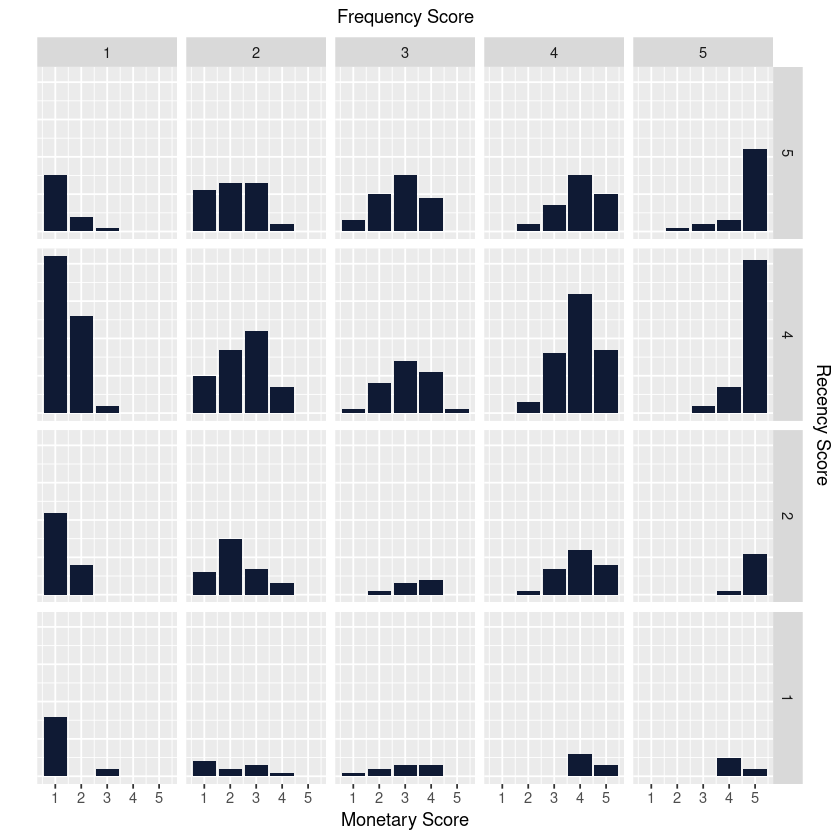

In [39]:
rfm_plot_bar_chart(rfm_score)

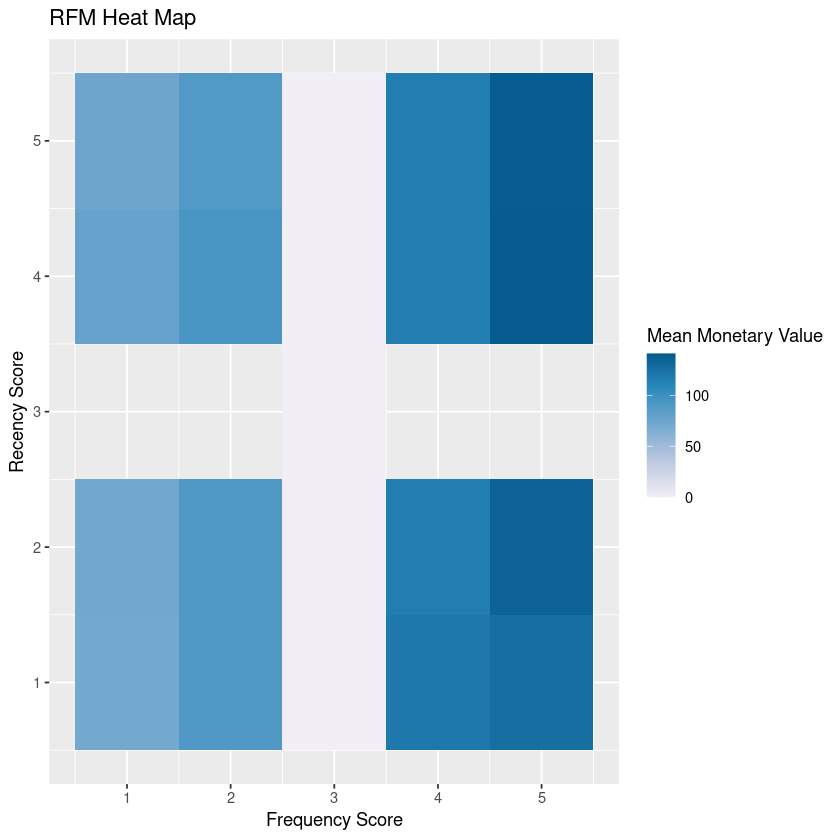

In [40]:
rfm_plot_heatmap(rfm_score)

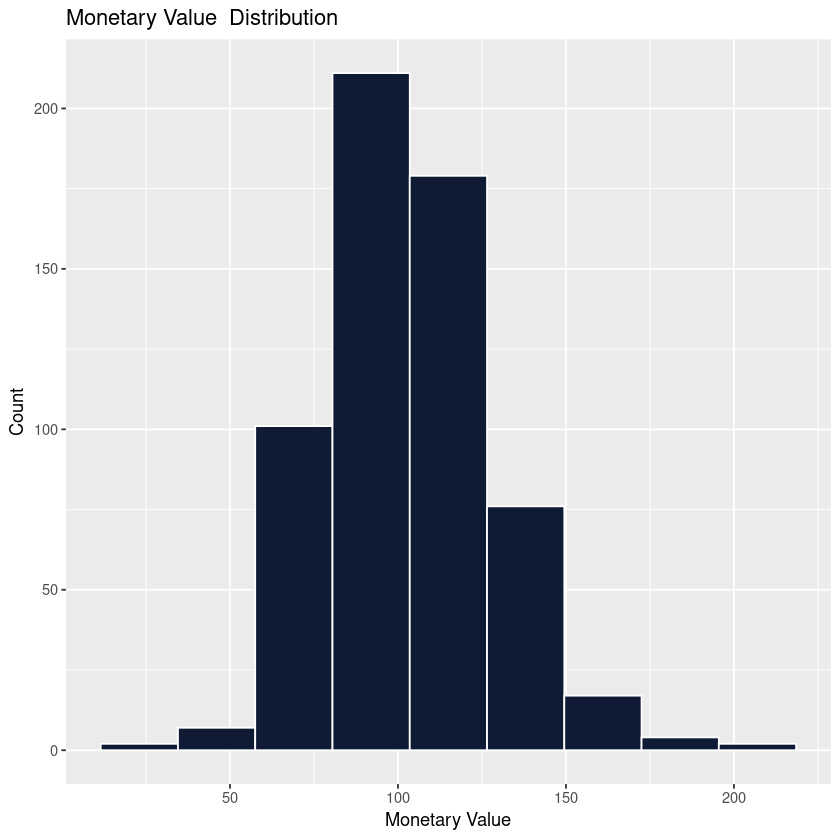

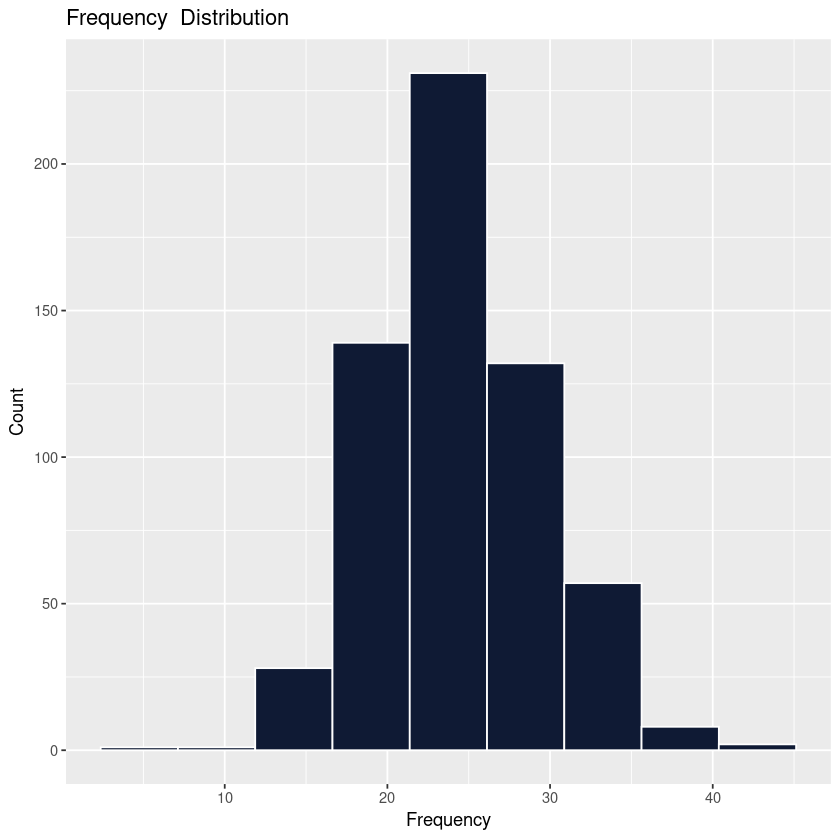

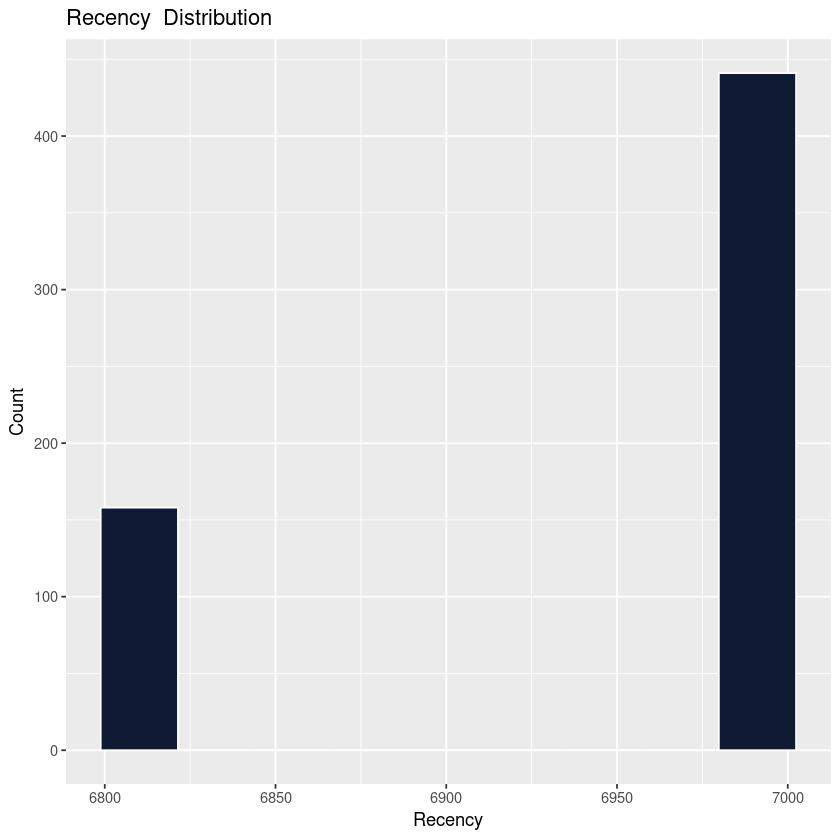

In [28]:
rfm_plot_histogram(rfm_score, metric = "monetary")
rfm_plot_histogram(rfm_score, metric = "frequency")
rfm_plot_histogram(rfm_score, metric = "recency")

## Customer Segmentation using RFM Scores

The RFM R Package has a great tutorial on segmentation into a preset number of categories based on their RFM scores on a 5 point scale. See below.

In [41]:

# segment names
segment_names <- c("Champions", "Potential Loyalist", "Loyal Customers",
"Promising", "New Customers", "Can't Lose Them",
"At Risk", "Need Attention", "About To Sleep", "Lost")

# segment intervals
recency_lower <- c(5, 3, 2, 3, 4, 1, 1, 1, 2, 1)
recency_upper <- c(5, 5, 4, 4, 5, 2, 2, 3, 3, 1)
frequency_lower <- c(5, 3, 2, 1, 1, 3, 2, 3, 1, 1)
frequency_upper <- c(5, 5, 4, 3, 3, 4, 5, 5, 3, 5)
monetary_lower <- c(5, 2, 2, 3, 1, 4, 4, 3, 1, 1)
monetary_upper <- c(5, 5, 4, 5, 5, 5, 5, 5, 4, 5)

# to interpret this code, lets look at loyal customers. They are the third position in the segment_names variable. They have a lower bound of recency of 2 and upper bound of 4. They have a lower bound of frequency of 2 and upper bound of 4 and a lower bount of monetary and upper bound of 4)

# generate segments
segments <- rfm_segment(rfm_score, segment_names, recency_lower, recency_upper, frequency_lower, frequency_upper, monetary_lower, monetary_upper)

# rfm_create_report(rfm_score, segments, FALSE,"Customer Segmentation Report")

In [42]:
segment_overview <- rfm_segment_summary(segments)

In [43]:
segment_overview

#aov stands for average order value

segment,customers,orders,revenue,aov
<chr>,<int>,<int>,<dbl>,<dbl>
About To Sleep,36,648,2617,4.04
At Risk,20,611,2614,4.28
Can't Lose Them,20,543,2474,4.56
Champions,22,737,3224,4.37
Lost,30,572,2316,4.05
Loyal Customers,99,2307,9891,4.29
Need Attention,3,72,299,4.15
New Customers,141,2796,11418,4.08
Potential Loyalist,226,6272,26410,4.21


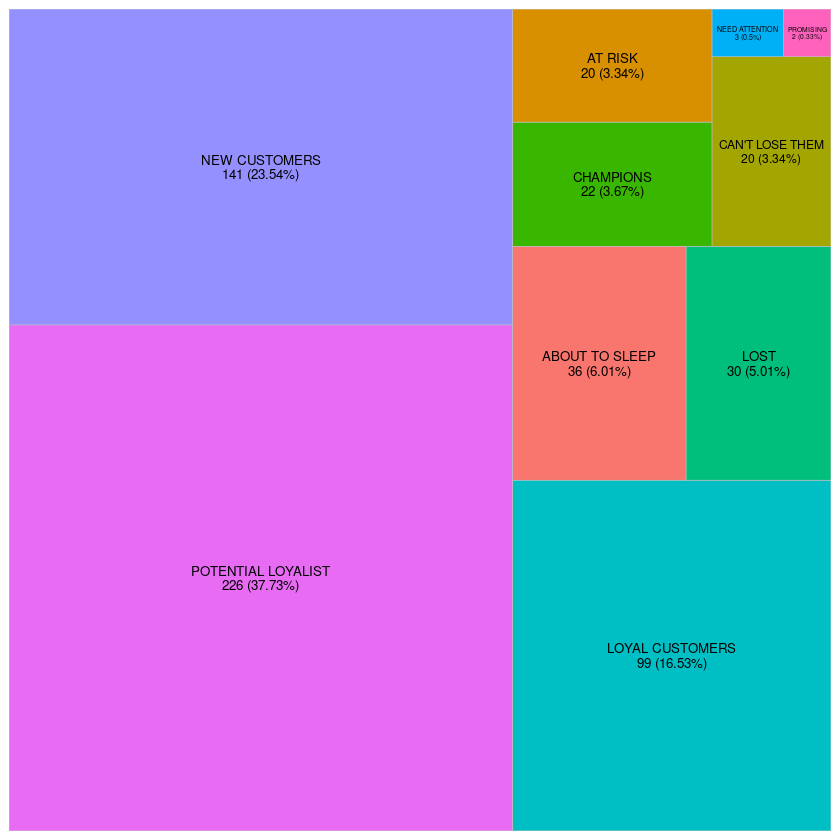

In [44]:
rfm_plot_segment(segment_overview)

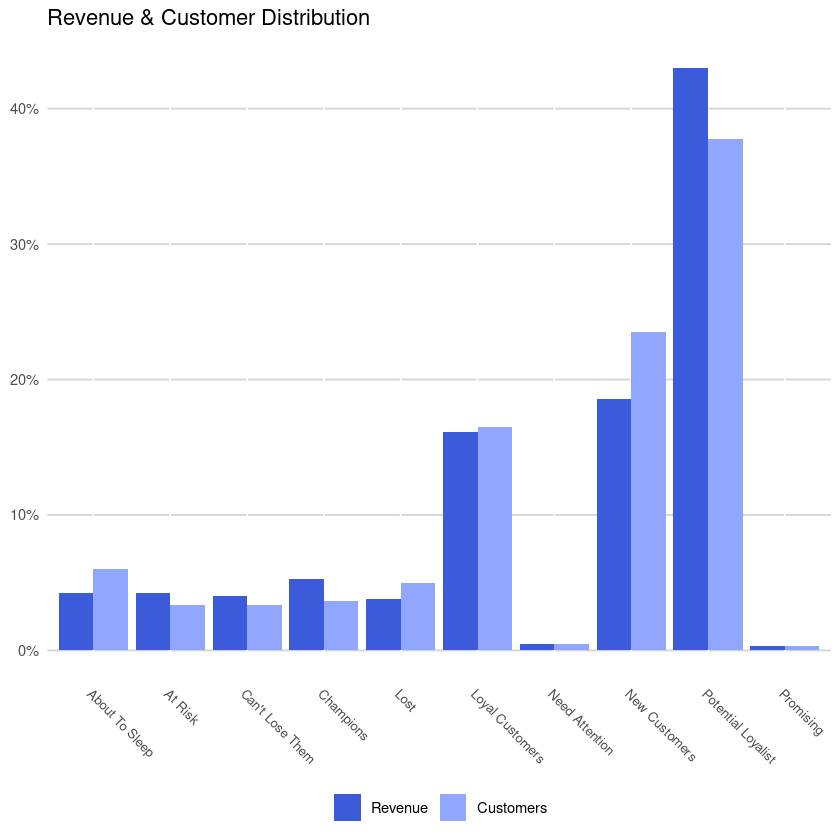

In [45]:
rfm_plot_revenue_dist(segment_overview)

# But we haven't used the rental information in the rental_more table. Can you repeat this analysis after joining the rental and rental_more table?

Hint: Use UNION.

Hint: Make sure you reconstruct the query from scratch and select the right columns from the right tables